In [1]:
import numpy as np

N=500
x = np.linspace(-1, 1, N)
# np.random.seed(0)
# x = np.sort(np.random.uniform(-1, 1, N))

Construct the matrix

In [2]:
A = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        if i == j:
            A[i,j] = 100
        else:
            A[i,j] = 1/abs(x[i]-x[j])

In [3]:
A

array([[100.        , 249.5       , 124.75      , ...,   0.50201207,
          0.50100402,   0.5       ],
       [249.5       , 100.        , 249.5       , ...,   0.50302419,
          0.50201207,   0.50100402],
       [124.75      , 249.5       , 100.        , ...,   0.5040404 ,
          0.50302419,   0.50201207],
       ...,
       [  0.50201207,   0.50302419,   0.5040404 , ..., 100.        ,
        249.5       , 124.75      ],
       [  0.50100402,   0.50201207,   0.50302419, ..., 249.5       ,
        100.        , 249.5       ],
       [  0.5       ,   0.50100402,   0.50201207, ..., 124.75      ,
        249.5       , 100.        ]])

## Matrix Visualisation

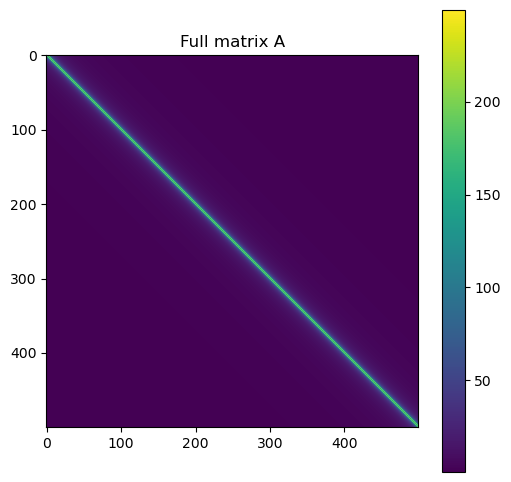

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(A, cmap="viridis")
plt.colorbar()
plt.title("Full matrix A")
plt.show()


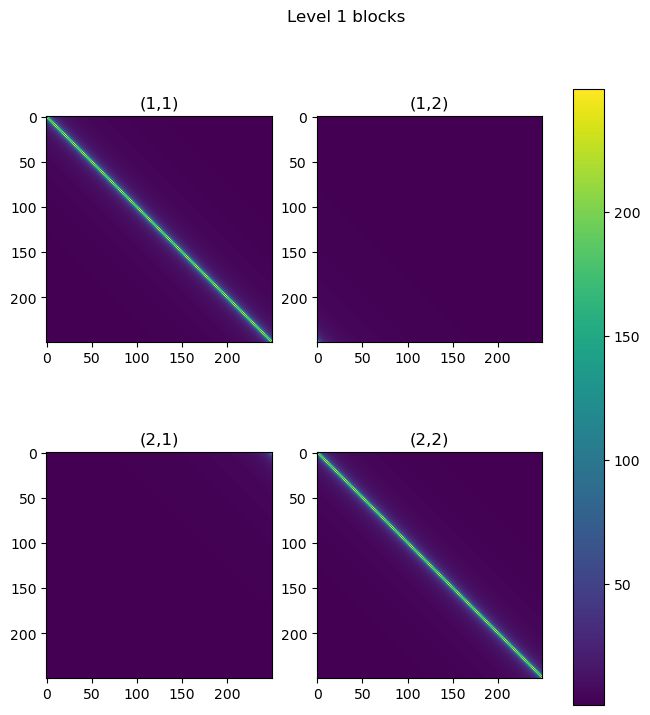

In [5]:
mid1 = N // 2

blocks_L1 = [
    A[:mid1, :mid1],
    A[:mid1, mid1:],
    A[mid1:, :mid1],
    A[mid1:, mid1:]
]

fig, axs = plt.subplots(2, 2, figsize=(8, 8))

for ax, blk, title in zip(
    axs.flat,
    blocks_L1,
    ["(1,1)", "(1,2)", "(2,1)", "(2,2)"]
):
    im = ax.imshow(blk, cmap="viridis")
    ax.set_title(title)

cbar = fig.colorbar(im, ax=axs)

plt.suptitle("Level 1 blocks")
plt.show()


# H Matrices Implementation

In [6]:
def split_indices(start, end):
    mid = (start + end)//2
    return (start, mid), (mid, end)

In [7]:
def numerical_rank(block, eps=1e-6):
    U, S, Vt = np.linalg.svd(block)
    S_norm = S / S[0] #normalising
    rank = np.sum(S_norm > eps)
    return rank, S_norm

## Naive

In [8]:
def hierarchical_svd(A, row_range, col_range, level, max_level, results):
    r0, r1 = row_range
    c0, c1 = col_range
    block = A[r0:r1, c0:c1]

    rank, svals = numerical_rank(block)
    results.append({
        "level": level,
        "row_range": row_range,
        "col_range": col_range,
        "shape": block.shape,
        "rank": rank,
        "singular_values": svals
    })
    if level == max_level:
        return

    (rL, rR) = split_indices(r0, r1)
    (cL, cR) = split_indices(c0, c1)

    hierarchical_svd(A, rL, cL, level+1, max_level, results)
    hierarchical_svd(A, rL, cR, level+1, max_level, results)
    hierarchical_svd(A, rR, cL, level+1, max_level, results)
    hierarchical_svd(A, rR, cR, level+1, max_level, results)


In [9]:
results = []
hierarchical_svd(
    A,
    row_range=(0, N),
    col_range=(0, N),
    level=0,
    max_level=3,
    results=results
)


In [10]:
for r in results:
    # if r["level"] == 2:
        print(
            f"L{r['level']} | rows {r['row_range']} cols {r['col_range']} "
            f"| shape {r['shape']} | numerical rank = {r['rank']}"
        )


L0 | rows (0, 500) cols (0, 500) | shape (500, 500) | numerical rank = 500
L1 | rows (0, 250) cols (0, 250) | shape (250, 250) | numerical rank = 250
L2 | rows (0, 125) cols (0, 125) | shape (125, 125) | numerical rank = 125
L3 | rows (0, 62) cols (0, 62) | shape (62, 62) | numerical rank = 62
L3 | rows (0, 62) cols (62, 125) | shape (62, 63) | numerical rank = 9
L3 | rows (62, 125) cols (0, 62) | shape (63, 62) | numerical rank = 9
L3 | rows (62, 125) cols (62, 125) | shape (63, 63) | numerical rank = 63
L2 | rows (0, 125) cols (125, 250) | shape (125, 125) | numerical rank = 10
L3 | rows (0, 62) cols (125, 187) | shape (62, 62) | numerical rank = 4
L3 | rows (0, 62) cols (187, 250) | shape (62, 63) | numerical rank = 3
L3 | rows (62, 125) cols (125, 187) | shape (63, 62) | numerical rank = 9
L3 | rows (62, 125) cols (187, 250) | shape (63, 63) | numerical rank = 4
L2 | rows (125, 250) cols (0, 125) | shape (125, 125) | numerical rank = 10
L3 | rows (125, 187) cols (0, 62) | shape (62

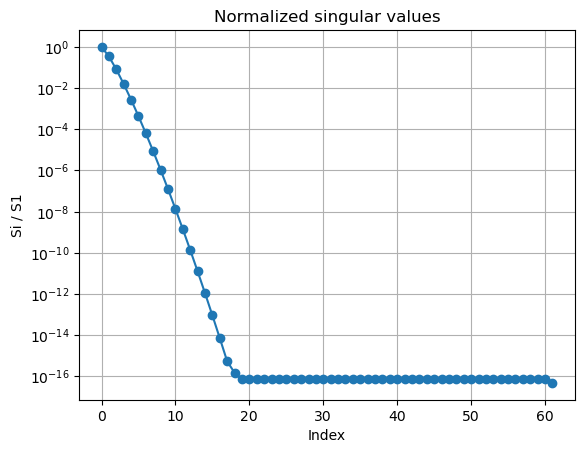

9


In [11]:
import matplotlib.pyplot as plt

example = results[10]   # pick any off-diagonal block
plt.semilogy(example["singular_values"], 'o-')
plt.xlabel("Index")
plt.ylabel("Si / S1")
plt.title("Normalized singular values")
plt.grid(True)
plt.show()
print(example["rank"])

## Better

In [12]:
def isLowRankMatrix(row_range, col_range): #checking if matrix is off diagonal (off diagonal => low-rank)
    r0, r1 = row_range
    c0, c1 = col_range

    # overlap check
    isOffDiag = r1 <= c0 or c1 <= r0
    
    return isOffDiag

In [13]:
def hierarchical_hmatrix(A, row_range, col_range, level=0,max_level=3):

    r0, r1 = row_range
    c0, c1 = col_range
    block = A[r0:r1, c0:c1]

    # case1: low rank block
    if isLowRankMatrix(row_range, col_range):
        rank,_ = numerical_rank(block)
        print(
            f"[LOW-RANK] L{level} "
            f"rows {row_range} cols {col_range} "
            f"shape {block.shape} rank={rank}"
        )
        return

    # case2: dense leaf
    if level == max_level:
        print(
            f"[DENSE LEAF] L{level} "
            f"rows {row_range} cols {col_range} "
            f"shape {block.shape}"
        )
        return

    # case3: recursing within dense 
    print(
        f"[DENSE RECURSION] L{level} "
        f"rows {row_range} cols {col_range} "
        f"shape {block.shape}"
    )

    (rL, rR) = split_indices(r0, r1)
    (cL, cR) = split_indices(c0, c1)

    hierarchical_hmatrix(A, rL, cL, level+1, max_level)
    hierarchical_hmatrix(A, rL, cR, level+1, max_level)
    hierarchical_hmatrix(A, rR, cL, level+1, max_level)
    hierarchical_hmatrix(A, rR, cR, level+1, max_level)


In [14]:
results = []
hierarchical_hmatrix(
    A,
    row_range=(0, N),
    col_range=(0, N)
)


[DENSE RECURSION] L0 rows (0, 500) cols (0, 500) shape (500, 500)
[DENSE RECURSION] L1 rows (0, 250) cols (0, 250) shape (250, 250)
[DENSE RECURSION] L2 rows (0, 125) cols (0, 125) shape (125, 125)
[DENSE LEAF] L3 rows (0, 62) cols (0, 62) shape (62, 62)
[LOW-RANK] L3 rows (0, 62) cols (62, 125) shape (62, 63) rank=9
[LOW-RANK] L3 rows (62, 125) cols (0, 62) shape (63, 62) rank=9
[DENSE LEAF] L3 rows (62, 125) cols (62, 125) shape (63, 63)
[LOW-RANK] L2 rows (0, 125) cols (125, 250) shape (125, 125) rank=10
[LOW-RANK] L2 rows (125, 250) cols (0, 125) shape (125, 125) rank=10
[DENSE RECURSION] L2 rows (125, 250) cols (125, 250) shape (125, 125)
[DENSE LEAF] L3 rows (125, 187) cols (125, 187) shape (62, 62)
[LOW-RANK] L3 rows (125, 187) cols (187, 250) shape (62, 63) rank=9
[LOW-RANK] L3 rows (187, 250) cols (125, 187) shape (63, 62) rank=9
[DENSE LEAF] L3 rows (187, 250) cols (187, 250) shape (63, 63)
[LOW-RANK] L1 rows (0, 250) cols (250, 500) shape (250, 250) rank=11
[LOW-RANK] L1 row

# SVD Implementation

In [15]:
A.shape

(500, 500)

In [16]:
X = np.ones(N)
X.shape

(500,)

In [17]:
def og_mult(A, x):
    m, n = A.shape
    y = np.zeros(m)
    
    for i in range(m):
        for j in range(n):
            y[i] += A[i,j] * x[j]
            
    return y


In [18]:
class HMatrix:
    def __init__(self, A, max_level=4, eps=1e-6):
        self.A = A
        self.N = A.shape[0]
        self.max_level = max_level
        self.eps = eps
        self.blocks = {}   # store dense blocks fully and (U,S,Vt) for low rank
        
        self.build((0, self.N), (0, self.N), level=0)

    def build(self, row_range, col_range, level):
        r0, r1 = row_range
        c0, c1 = col_range

        block = self.A[r0:r1, c0:c1]
    
        # case1: low rank block
        if isLowRankMatrix(row_range, col_range):
    
            U, S, Vt = np.linalg.svd(block, full_matrices=False)
            S_norm = S / S[0]
            rank = np.sum(S_norm > self.eps)
            
            U = U[:, :rank]
            S = np.diag(S[:rank])
            Vt = Vt[:rank, :]
            
            self.blocks[(row_range, col_range)] = ("lowrank", U, S, Vt)
            return
    
        # case2: dense leaf block
        if level == self.max_level:
            self.blocks[(row_range, col_range)] = ("dense", block)
            return
        
        # case3: recursion
        rL, rR = split_indices(r0, r1)
        cL, cR = split_indices(c0, c1)
        
        self.build(rL, cL, level+1)
        self.build(rL, cR, level+1)
        self.build(rR, cL, level+1)
        self.build(rR, cR, level+1)

    def mult(self, x):
        y = np.zeros_like(x) #result matrix y 
        
        for (row_range, col_range), block_data in self.blocks.items():
            r0, r1 = row_range
            c0, c1 = col_range
            
            if block_data[0] == "dense":
                block = block_data[1]
                y[r0:r1] += block @ x[c0:c1]
            
            else:
                _,U,S,Vt = block_data
                y[r0:r1] += U @ (S @ (Vt @ x[c0:c1]))
                # y[r0:r1] += og_mult(U,og_mult(S,(og_mult(Vt,x[c0:c1]))))
        
        return y

In [19]:
y_real = A @ X
y_real

array([1794.31044578, 2043.31044578, 2167.55944177, 2250.22409636,
       2312.09607217, 2361.49203176, 2402.57030437, 2437.70707632,
       2468.3874625 , 2495.60153808, 2520.04235441, 2542.21394764,
       2562.49434381, 2581.17433118, 2598.48238526, 2614.60128561,
       2629.67953974, 2643.83944718, 2657.18292344, 2669.79579137,
       2681.7509997 , 2693.11107525, 2703.93001782, 2714.25478311,
       2724.12645678, 2733.58119362, 2742.65097616, 2751.36423275,
       2759.74634534, 2767.82006963, 2775.60588523, 2783.12228939,
       2790.38604473, 2797.41238955, 2804.21521712, 2810.8072294 ,
       2817.20006944, 2823.4044358 , 2829.43018198, 2835.28640313,
       2840.98151182, 2846.52330469, 2851.91902106, 2857.17539478,
       2862.2987002 , 2867.294793  , 2872.16914657, 2876.92688458,
       2881.5728101 , 2886.11143175, 2890.54698731, 2894.88346488,
       2899.12462216, 2903.27400379, 2907.33495712, 2911.3106466 ,
       2915.2040668 , 2919.01805437, 2922.75529887, 2926.41835

In [20]:
H = HMatrix(A, max_level=4)
y_h = H.mult(X)
y_h

array([1794.31044454, 2043.31044494, 2167.55944128, 2250.22409618,
       2312.09607224, 2361.49203204, 2402.57030479, 2437.70707683,
       2468.38746304, 2495.60153859, 2520.04235483, 2542.21394794,
       2562.49434394, 2581.17433111, 2598.482385  , 2614.60128516,
       2629.67953915, 2643.83944652, 2657.1829228 , 2669.79579088,
       2681.7509995 , 2693.11107545, 2703.93001843, 2714.25478402,
       2724.12645763, 2733.58119386, 2742.65097533, 2751.36423153,
       2759.74634661, 2767.82006938, 2775.60588527, 2783.12228943,
       2790.38604449, 2797.41239082, 2804.21521591, 2810.8072286 ,
       2817.20006971, 2823.40443668, 2829.43018293, 2835.28640379,
       2840.98151207, 2846.52330456, 2851.91902064, 2857.17539421,
       2862.29869961, 2867.29479247, 2872.16914618, 2876.92688437,
       2881.57281007, 2886.11143191, 2890.54698763, 2894.88346534,
       2899.12462272, 2903.27400441, 2907.33495776, 2911.3106472 ,
       2915.20406728, 2919.0180546 , 2922.75529877, 2926.41835

In [21]:
print("Relative error: ", np.linalg.norm(y_real - y_h)/np.linalg.norm(y_real))

Relative error:  1.42774564827408e-10


In [22]:
print("Number of stored blocks:", len(H.blocks))

Number of stored blocks: 46


## Plots

### Memory

In [23]:
def HMatrixMemory(H):
    mem = 0
    
    for block_data in H.blocks.values():
        if block_data[0] == "dense":
            block = block_data[1]
            mem += block.size
            
        else:
            _, U, S, Vt = block_data
            mem += U.size + S.size + Vt.size
            
    return mem


In [24]:
def HMatrixMemory_LR(H):
    mem = 0
    
    for block_data in H.blocks.values():
        if block_data[0] == "lowrank":
            _, U, S, Vt = block_data
            mem += U.size + S.size + Vt.size
            
    return mem


In [25]:
Ns = [128, 256, 384, 512,1024]
og_memory = []
h_memory = []
h_lr_memory = []
level = 3  # fixed level

for N in Ns:
    x = np.linspace(-1, 1, N)
    A = np.zeros((N, N))
    
    for i in range(N):
        for j in range(N):
            if i == j:
                A[i,j] = 100
            else:
                A[i,j] = 1/abs(x[i] - x[j])
                
    og_memory.append(A.size)

    H = HMatrix(A, max_level=level)
    h_memory.append(HMatrixMemory(H))
    h_lr_memory.append(HMatrixMemory_LR(H))



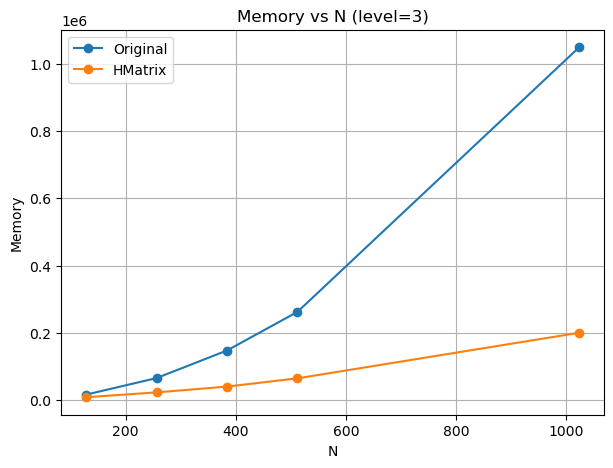

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(Ns, og_memory, 'o-', label="Original")
plt.plot(Ns, h_memory, 'o-', label="HMatrix")

plt.xlabel("N")
plt.ylabel("Memory")
plt.title(f"Memory vs N (level={level})")

plt.legend()
plt.grid(True)
plt.show()


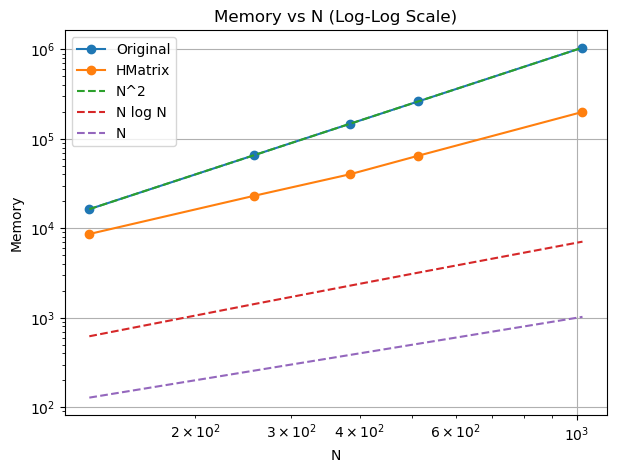

In [27]:
plt.figure(figsize=(7,5))

plt.loglog(Ns, og_memory, 'o-', label="Original")
plt.loglog(Ns, h_memory, 'o-', label="HMatrix")

# Reference curves
ref_n2 = [N**2 for N in Ns]
ref_nlogn = [N*np.log(N) for N in Ns]
ref_n = [N for N in Ns]

plt.loglog(Ns, ref_n2, '--', label="N^2")
plt.loglog(Ns, ref_nlogn, '--', label="N log N")
plt.loglog(Ns, ref_n, '--', label="N")

plt.xlabel("N")
plt.ylabel("Memory")
plt.title("Memory vs N (Log-Log Scale)")
plt.legend()
plt.grid(True)

plt.show()


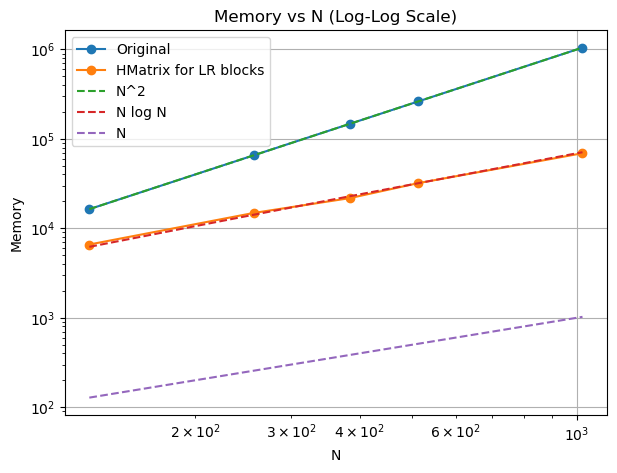

In [28]:
plt.figure(figsize=(7,5))

plt.loglog(Ns, og_memory, 'o-', label="Original")
plt.loglog(Ns, h_lr_memory, 'o-', label="HMatrix for LR blocks")

# Reference curves
ref_n2 = [N**2 for N in Ns]
ref_nlogn = [10*N*np.log(N) for N in Ns]
ref_n = [N for N in Ns]

plt.loglog(Ns, ref_n2, '--', label="N^2")
plt.loglog(Ns, ref_nlogn, '--', label="N log N")
plt.loglog(Ns, ref_n, '--', label="N")

plt.xlabel("N")
plt.ylabel("Memory")
plt.title("Memory vs N (Log-Log Scale)")
plt.legend()
plt.grid(True)

plt.show()


In [29]:
N = 512
levels = [1, 2, 3, 4, 5, 6, 7]

memory_by_level = []

x = np.linspace(-1, 1, N)
A = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        if i == j:
            A[i,j] = 100
        else:
            A[i,j] = 1/abs(x[i] - x[j])

for lvl in levels:    
    H = HMatrix(A, max_level=lvl)
    memory_by_level.append(HMatrixMemory(H))


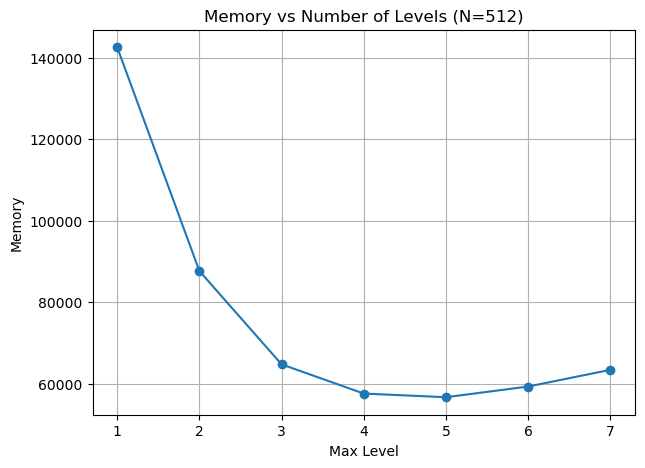

In [30]:
plt.figure(figsize=(7,5))

plt.plot(levels, memory_by_level, 'o-')

plt.xlabel("Max Level")
plt.ylabel("Memory")
plt.title(f"Memory vs Number of Levels (N={N})")
plt.grid(True)
plt.show()


### Time

In [31]:
def og_mult(A, x):
    m, n = A.shape
    y = np.zeros(m)
    
    for i in range(m):
        for j in range(n):
            y[i] += A[i,j] * x[j]
            
    return y


In [32]:
import time
import numpy as np

Ns = [128, 256, 384, 512, 1024]

og_times = []
h_times = []

level = 2  # keep fixed

for N in Ns:
    x = np.linspace(-1, 1, N)
    
    A = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            if i == j:
                A[i,j] = 100
            else:
                A[i,j] = 1/abs(x[i] - x[j])
    
    X = np.ones(N)
    
    H = HMatrix(A, max_level=level)
    
    # Normal NxN matrix mult timing
    t0 = time.perf_counter()
    # A @ X
    og_mult(A,X)
    og_times.append(time.perf_counter() - t0)
    
    # H Matrix multiplication
    t0 = time.perf_counter()
    H.mult(X)
    h_times.append(time.perf_counter() - t0)


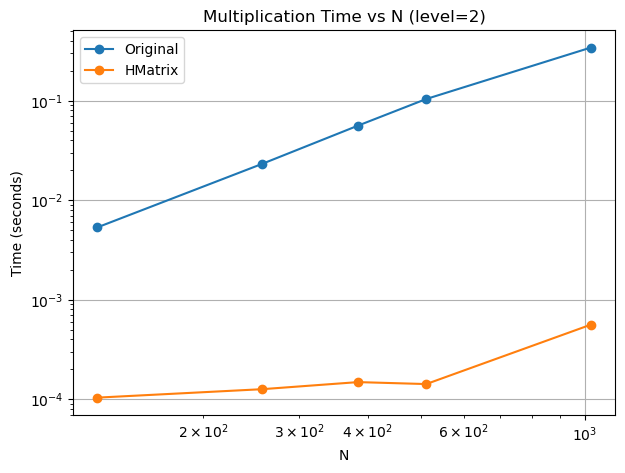

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.loglog(Ns, og_times, 'o-', label="Original")
plt.loglog(Ns, h_times, 'o-', label="HMatrix")

plt.xlabel("N")
plt.ylabel("Time (seconds)")
plt.title(f"Multiplication Time vs N (level={level})")

plt.legend()
plt.grid(True)
plt.show()


In [34]:
import numpy as np
import time
import matplotlib.pyplot as plt

N = 512
levels = [1, 2, 3, 4, 5, 6, 7]

x = np.linspace(-1, 1, N)

A = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        if i == j:
            A[i,j] = 100
        else:
            A[i,j] = 1/abs(x[i] - x[j])

X = np.ones(N)

In [35]:
times_by_level = []

for lvl in levels:
    H = HMatrix(A, max_level=lvl)
    
    repeats = 100   # increase for stability
    
    t0 = time.perf_counter()
    for _ in range(repeats):
        H.mult(X)
    t = (time.perf_counter() - t0) / repeats
    
    times_by_level.append(t)


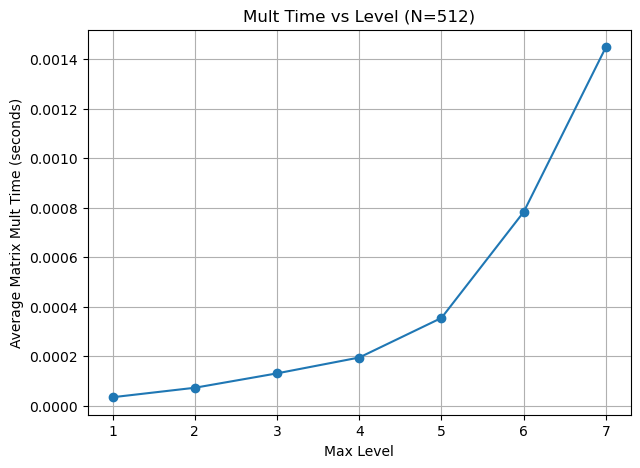

In [36]:
plt.figure(figsize=(7,5))

plt.plot(levels, times_by_level, 'o-')

plt.xlabel("Max Level")
plt.ylabel("Average Matrix Mult Time (seconds)")
plt.title(f"Mult Time vs Level (N={N})")

plt.grid(True)
plt.show()


# Chebyshev Implementation

In [37]:
import numpy as np
from scipy.stats import norm

In [38]:
# def chebyshev_polynomials(x, p):
#     x = np.asarray(x)
#     T = np.zeros((len(x), p))

#     T[:, 0] = 1.0
#     if p > 1:
#         T[:, 1] = x

#     for n in range(2, p):
#         T[:, n] = 2 * x * T[:, n-1] - T[:, n-2]

#     return T


# def chebyshev_points(p):
#     k = np.arange(p)
#     return np.cos((2 * k + 1) * np.pi / (2 * p))


# def scale_to_minus1_1(x, a, b):
#     return (2 * x - (a + b)) / (b - a)


In [39]:
# def kernel_entry(z_i, x_j, h):
#     """
#     Returns single kernel matrix entry.
#     K_ij = Phi((z_i - x_j)/h)
#     """
#     return norm.cdf((z_i - x_j) / h)


# def kernel_matrix(z_block, x_block, h):
#     """
#     Build full kernel matrix using entry definition.
#     (Clear mathematically — not optimized for speed)
#     """
#     Nz = len(z_block)
#     Nx = len(x_block)

#     K = np.zeros((Nz, Nx))

#     for i in range(Nz):
#         for j in range(Nx):
#             K[i, j] = kernel_entry(z_block[i], x_block[j], h)

#     return K


In [52]:
def kernel_entry(x_i, x_j):
    if x_i == x_j:
        return 100.0
    else:
        return 1.0 / abs(x_i - x_j)

def kernel_matrix(x_block, y_block):
    Nx = len(x_block)
    Ny = len(y_block)

    K = np.zeros((Nx, Ny))

    for i in range(Nx):
        for j in range(Ny):
            K[i,j] = kernel_entry(x_block[i], y_block[j])

    return K


def chebyshev_points(p):
    k = np.arange(p)
    return np.cos((2*k+1)*np.pi/(2*p))

def chebyshev_polynomials(x, p):
    x = np.asarray(x)
    T = np.zeros((len(x), p))

    T[:,0] = 1.0
    if p > 1:
        T[:,1] = x

    for n in range(2,p):
        T[:,n] = 2*x*T[:,n-1] - T[:,n-2]

    return T

def scale_to_minus1_1(x,a,b):
    return (2*x - (a+b)) / (b-a)


def build_interpolation_matrix(x_block, p):

    a,b = x_block.min(), x_block.max()

    x_scaled = scale_to_minus1_1(x_block, a, b)

    T = chebyshev_polynomials(x_scaled, p)

    t = chebyshev_points(p)
    Tt = chebyshev_polynomials(t, p)

    gamma = np.ones(p)
    gamma[0] = 0.5
    W = (2/p)*gamma

    return T @ (W[:,None]*Tt.T)


def compute_S_block(x_row, x_col, p):

    t = chebyshev_points(p)

    ar, br = x_row.min(), x_row.max()
    ac, bc = x_col.min(), x_col.max()

    xr = 0.5*(br-ar)*t + 0.5*(br+ar)
    xc = 0.5*(bc-ac)*t + 0.5*(bc+ac)

    return kernel_matrix(xr, xc)

In [55]:
class HMatrixCheb:

    def __init__(self, x, p=8, max_level=4):

        self.x = x
        self.N = len(x)
        self.p = p
        self.max_level = max_level

        self.blocks = {}
        self.row_clusters = {}
        self.col_clusters = {}

        self.build((0,self.N),(0,self.N), level=0)


    def build_row_cluster(self, row_range):

        if row_range in self.row_clusters:
            return

        r0,r1 = row_range
        x_row = self.x[r0:r1]

        U = build_interpolation_matrix(x_row, self.p)

        self.row_clusters[row_range] = U


    def build_col_cluster(self, col_range):

        if col_range in self.col_clusters:
            return

        c0,c1 = col_range
        x_col = self.x[c0:c1]

        V = build_interpolation_matrix(x_col, self.p)

        self.col_clusters[col_range] = V


    def build(self, row_range, col_range, level):

        r0,r1 = row_range
        c0,c1 = col_range

        # LOW RANK BLOCK
        if isLowRankMatrix(row_range, col_range):

            self.build_row_cluster(row_range)
            self.build_col_cluster(col_range)

            x_row = self.x[r0:r1]
            x_col = self.x[c0:c1]

            S = compute_S_block(x_row, x_col, self.p)

            self.blocks[(row_range,col_range)] = (
                "lowrank", row_range, col_range, S
            )
            return


        # DENSE LEAF
        if level == self.max_level:

            x_row = self.x[r0:r1]
            x_col = self.x[c0:c1]

            block = kernel_matrix(x_row, x_col)

            self.blocks[(row_range,col_range)] = (
                "dense", block
            )
            return


        # RECURSION
        rL,rR = split_indices(r0,r1)
        cL,cR = split_indices(c0,c1)

        self.build(rL,cL,level+1)
        self.build(rL,cR,level+1)
        self.build(rR,cL,level+1)
        self.build(rR,cR,level+1)


    def mult(self, v):

        y = np.zeros_like(v)

        for key, block in self.blocks.items():

            row_range, col_range = key
            r0,r1 = row_range
            c0,c1 = col_range

            if block[0] == "dense":

                y[r0:r1] += block[1] @ v[c0:c1]

            else:

                _, row_id, col_id, S = block

                U = self.row_clusters[row_id]
                V = self.col_clusters[col_id]

                y[r0:r1] += U @ (S @ (V.T @ v[c0:c1]))

        return y

# Comparisions

In [60]:
N = 500
x = np.linspace(0,1,N)
X = np.ones(N)

A = kernel_matrix_general(x,x)
y_exact = A @ X

# SVD H-matrix
H_svd = HMatrix(A)
y_svd = H_svd.mult(X)

# Chebyshev H-matrix
H_cheb = HMatrixCheb(x, p=8)
y_cheb = H_cheb.mult(X)

print("SVD error:",
      np.linalg.norm(y_exact - y_svd)/np.linalg.norm(y_exact))

print("Cheb error:",
      np.linalg.norm(y_exact - y_cheb)/np.linalg.norm(y_exact))


SVD error: 1.4519034330743149e-10
Cheb error: 0.011873694803946407


## Cheby Comps

In [80]:
def hmatrix_cheb_memory(H):

    total = 0

    for U in H.row_clusters.values():
        total += U.size

    for V in H.col_clusters.values():
        total += V.size

    for block in H.blocks.values():
        if block[0] == "dense":
            total += block[1].size
        else:
            S = block[3]
            total += S.size

    return total


In [74]:
N = 600
x = np.linspace(0,1,N)
X = np.ones(N)

A = kernel_matrix(x,x)
y_exact = A @ X

ps = [4, 6, 8, 10, 12, 16]

errors = []
times = []
mems = []
build_times = []

for p in ps:
    t0 = time.perf_counter()
    H = HMatrixCheb(x, p=p, max_level=4)
    build_times.append(time.perf_counter() - t0)

    # memory
    mems.append(hmatrix_cheb_memory(H))

    # matvec time
    t0 = time.perf_counter()
    y = H.mult(X)
    times.append(time.perf_counter() - t0)

    # error
    err = np.linalg.norm(y_exact-y)/np.linalg.norm(y_exact)
    errors.append(err)


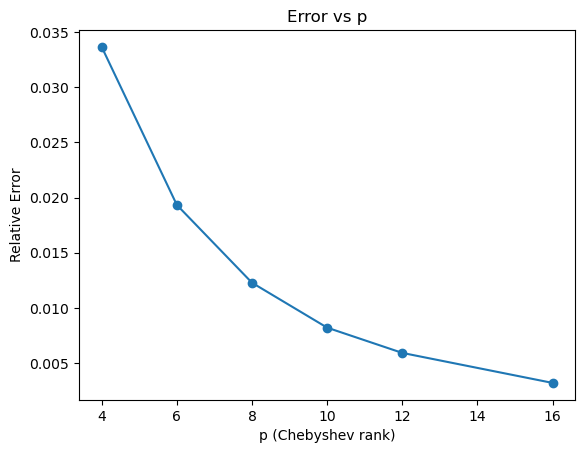

In [75]:
plt.figure()
plt.plot(ps, errors, 'o-')
plt.xlabel("p (Chebyshev rank)")
plt.ylabel("Relative Error")
plt.title("Error vs p")
plt.show()


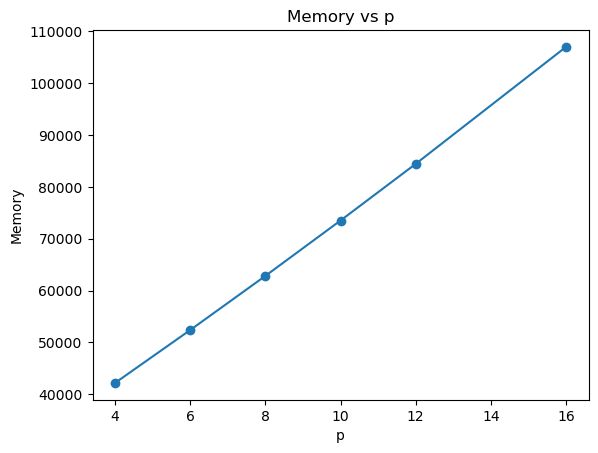

In [76]:
plt.figure()
plt.plot(ps, mems, 'o-')
plt.xlabel("p")
plt.ylabel("Memory")
plt.title("Memory vs p")
plt.show()


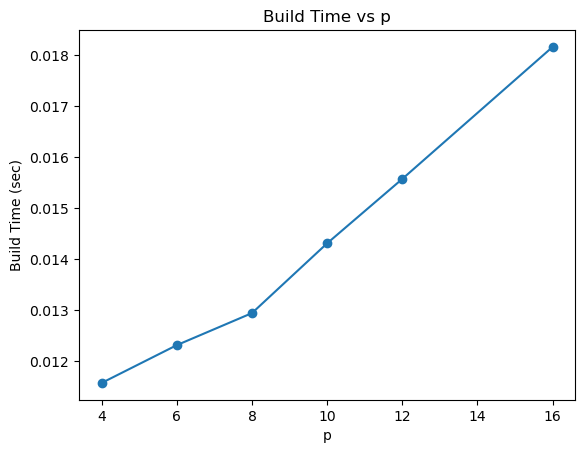

In [77]:
plt.figure()
plt.plot(ps, build_times, 'o-')
plt.xlabel("p")
plt.ylabel("Build Time (sec)")
plt.title("Build Time vs p")
plt.show()

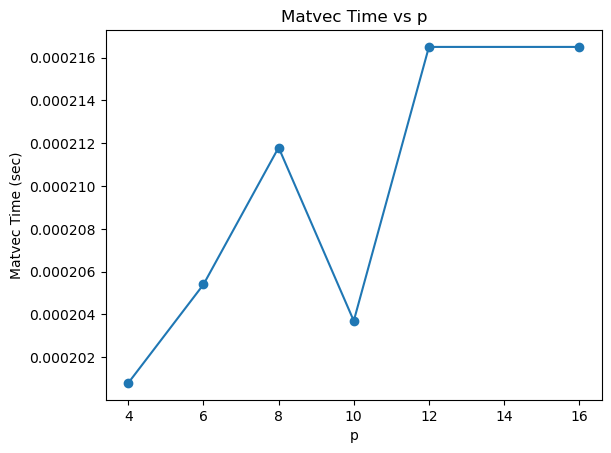

In [78]:
plt.figure()
plt.plot(ps, times, 'o-')
plt.xlabel("p")
plt.ylabel("Matvec Time (sec)")
plt.title("Matvec Time vs p")
plt.show()

## Dense vs SVD vs Cheby

In [79]:
def hmatrix_cheb_memory(H):

    total = 0

    for U in H.row_clusters.values():
        total += U.size

    for V in H.col_clusters.values():
        total += V.size

    for block in H.blocks.values():
        if block[0] == "dense":
            total += block[1].size
        else:
            S = block[3]
            total += S.size

    return total


In [99]:
import time
import matplotlib.pyplot as plt

Ns = [200, 400, 600, 800]

build_dense = []
build_svd = []
build_cheb = []

matvec_dense = []
matvec_svd = []
matvec_cheb = []

mem_dense = []
mem_svd = []
mem_cheb = []

for N in Ns:

    x = np.linspace(0,1,N)
    X = np.ones(N)

    # Original Matrix
    t0 = time.perf_counter()
    A = kernel_matrix(x,x)
    build_dense.append(time.perf_counter() - t0)

    mem_dense.append(A.size)

    t0 = time.perf_counter()
    y_exact = A @ X
    matvec_dense.append(time.perf_counter() - t0)


    # SVD
    t0 = time.perf_counter()
    H_svd = HMatrix(A)
    build_svd.append(time.perf_counter() - t0)

    mem_svd.append(HMatrixMemory(H_svd))

    t0 = time.perf_counter()
    y_svd = H_svd.mult(X)
    matvec_svd.append(time.perf_counter() - t0)

    # Cheby
    t0 = time.perf_counter()
    H_cheb = HMatrixCheb(x, p=8, max_level=4)
    build_cheb.append(time.perf_counter() - t0)

    mem_cheb.append(hmatrix_cheb_memory(H_cheb))

    t0 = time.perf_counter()
    y_cheb = H_cheb.mult(X)
    matvec_cheb.append(time.perf_counter() - t0)


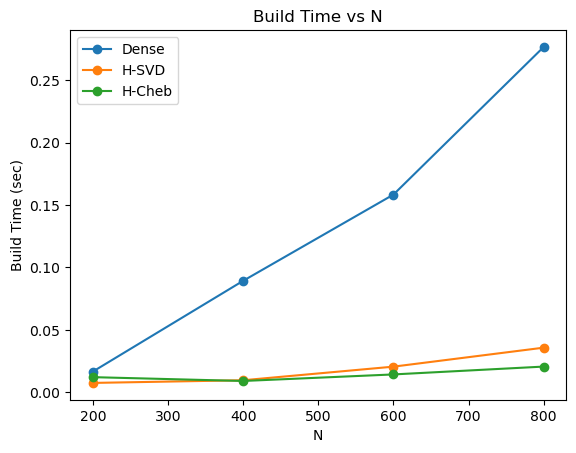

In [100]:
plt.figure()
plt.plot(Ns, build_dense, 'o-', label="Dense")
plt.plot(Ns, build_svd, 'o-', label="H-SVD")
plt.plot(Ns, build_cheb, 'o-', label="H-Cheb")
plt.xlabel("N")
plt.ylabel("Build Time (sec)")
plt.title("Build Time vs N")
plt.legend()
plt.show()


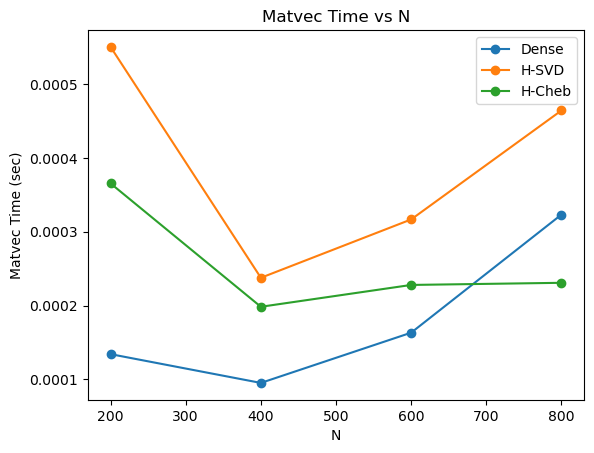

In [101]:
plt.figure()
plt.plot(Ns, matvec_dense, 'o-', label="Dense")
plt.plot(Ns, matvec_svd, 'o-', label="H-SVD")
plt.plot(Ns, matvec_cheb, 'o-', label="H-Cheb")
plt.xlabel("N")
plt.ylabel("Matvec Time (sec)")
plt.title("Matvec Time vs N")
plt.legend()
plt.show()


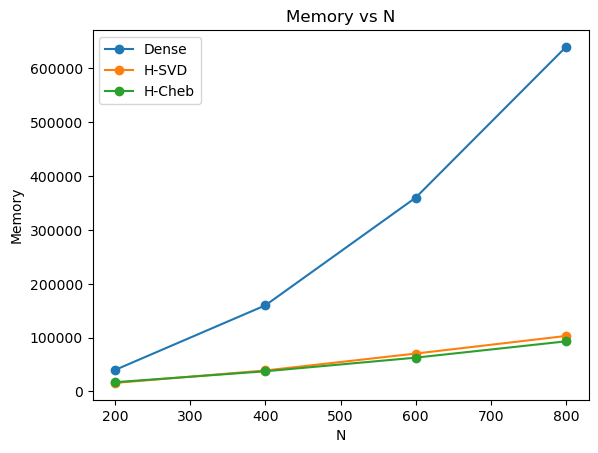

In [102]:
plt.figure()
plt.plot(Ns, mem_dense, 'o-', label="Dense")
plt.plot(Ns, mem_svd, 'o-', label="H-SVD")
plt.plot(Ns, mem_cheb, 'o-', label="H-Cheb")
plt.xlabel("N")
plt.ylabel("Memory")
plt.title("Memory vs N")
plt.legend()
plt.show()
